In [1]:
from tqdm import tqdm
from multiprocess import Pool
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from precip_ext_model import *
import cmcrameri.cm as cmc
import os

In [2]:
params={     
    'axes.labelsize'  : '14',   
    'axes.titlesize'  : '14',  
    'xtick.labelsize' :'14',
    'ytick.labelsize' :'14',    
    'lines.linewidth' : '2' ,   
    'legend.fontsize' : '12', 
    'figure.figsize'   : '12, 7'    
}
plt.rcParams.update(params)

In [3]:

def scatter_to_contour(x_in,y_in,z_in):
    # 1D scattered data
    x = np.asarray(x_in)
    y = np.asarray(y_in)
    z = np.asarray(z_in)

    # make regular grid
    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    Xi, Yi = np.meshgrid(xi, yi)

    # interpolate scattered data onto grid
    Zi = griddata((x, y), z, (Xi, Yi), method="linear")
    return Xi, Yi, Zi

In [4]:
def get_Palmer_plane(z_lcl=700,mprofile="cos",read_from_file=False):

    fname = f"Data/LCL_ext_{z_lcl}m_mprof-{mprofile}.csv"

    if os.path.exists(fname) & read_from_file:
       df = pd.read_csv(fname)
       return df

    # 1. Create (RH, P) pairs

    ## Use sequences
    #RH_values = np.linspace(0.01, 0.99, 50)
    #P_values = np.linspace(0, 20, 30)

    RH_values = np.linspace(0.02, 0.98, 25)
    P_values = np.linspace(0, 30, 31)


    param_pairs = [(RH, P) for RH in RH_values for P in P_values]

    # 2. Define worker function
    def worker(args):
        RH, P = args
        CAPE_u, CAPE_ext, dh, sat_def,dz,ent_b = spectral_plume_lcl(
            model_type="precip", RH=RH, P=P, z_lcl=z_lcl,mprofile=mprofile,
            get_plane=True, plotting=False, save_data=False
        )
        return CAPE_u, CAPE_ext, dh, sat_def, P, RH,dz,ent_b

    # 3. Run in parallel
    num_cpus = 8
    with Pool(processes=num_cpus) as pool:
        results = list(tqdm(pool.imap(worker, param_pairs), total=len(param_pairs)))


    # 4. Unpack results
    CAPEu_list, CAPEext_list, dh_list, sat_def_list, P_list,RH_list,dz_list,ent_b_list = zip(*results)
    CAPEu_list = list(CAPEu_list)
    CAPEext_list = list(CAPEext_list)
    dh_list = list(dh_list)
    sat_def_list = list(sat_def_list)
    P_list = list(P_list)
    RH_list = list(RH_list)
    dz_list = list(dz_list)
    ent_b_list = list(ent_b_list)

    # 5. Save to CSV
    df = pd.DataFrame({
        "CAPE_u":CAPEu_list,
        "CAPE_ext": CAPEext_list,
        "dh": dh_list,
        "sat_def": sat_def_list,
        "P": P_list,
        "RH": RH_list,
        "dz": dz_list,
        "ent_b":ent_b_list
                })
    df.to_csv(fname, index=False)

    return df

In [5]:

# Set the model parameters

z_lcl = 1400
mprofile = "cos"

df = get_Palmer_plane(z_lcl,mprofile,read_from_file=True)

In [6]:
## prepare arrays for plotting
sat_def_arr = np.array(df["sat_def"])*const.Lv0/1000
dh_arr = np.array(df["dh"])/1000
P_list = np.array(df["P"])/24
CAPEu_list = np.array(df["CAPE_u"])
CAPEext_list = np.array(df["CAPE_ext"])
w_arr = np.sqrt(2*CAPEext_list)
dz_arr = np.array(df["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df["ent_b"])*1000


In [7]:
## Set the plotting parameters
params={     
    'axes.labelsize'  : '14',   
    'axes.titlesize'  : '14',  
    'xtick.labelsize' :'14',
    'ytick.labelsize' :'14',    
    'lines.linewidth' : '2' ,   
    'legend.fontsize' : '12', 
    'figure.figsize'   : '12, 7'    
}
plt.rcParams.update(params)

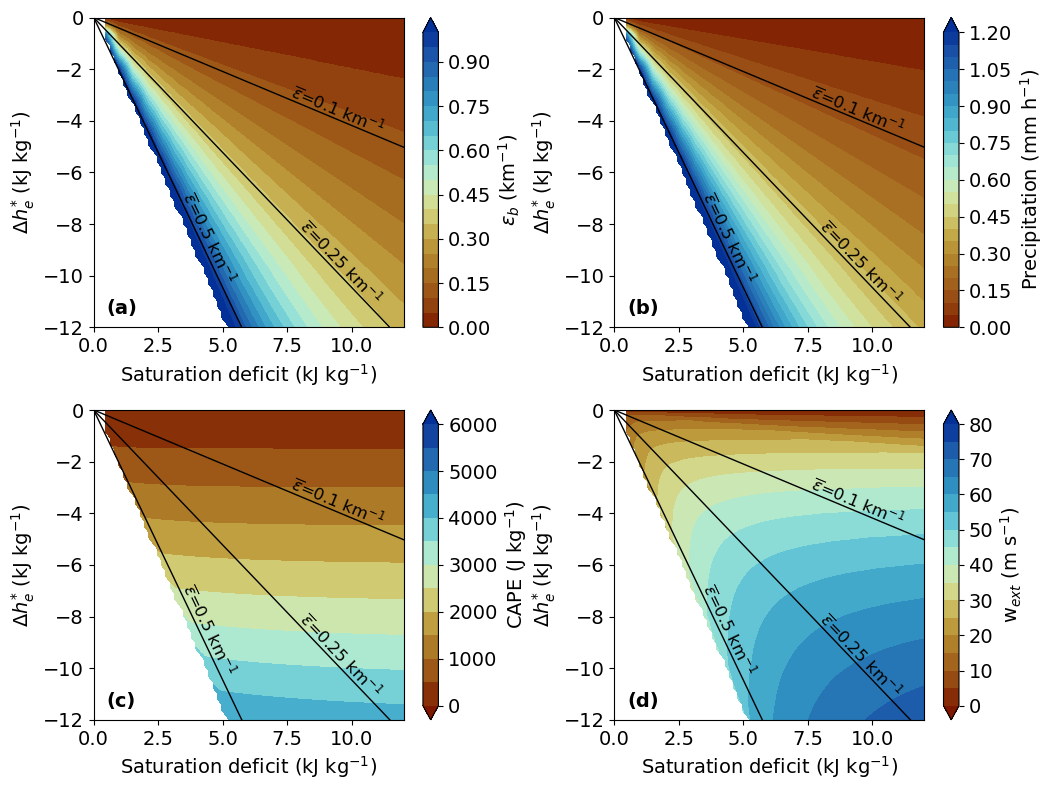

In [8]:

fig = plt.figure(figsize=(10.5,8))

ax1 = fig.add_subplot(222)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, np.array(P_list))
cf1 = ax1.contourf(Xi, Yi, Zi, levels=np.arange(0,1.25,0.05),extend="max",cmap=cmc.roma)
fig.colorbar(cf1, ax=ax1, label="Precipitation (mm h$^{-1}$)")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,12)
ax1.set_ylim(-12,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(b)",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')

ax2 = fig.add_subplot(223)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, CAPEu_list)
cf2 = ax2.contourf(Xi, Yi, Zi,levels=np.linspace(0,6000,13),extend="both",cmap=cmc.roma)
fig.colorbar(cf2, ax=ax2,label=r"CAPE (J kg$^{-1}$)")
for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )
ax2.set_xlim(0,12)
ax2.set_ylim(-12,0)
ax2.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax2.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax2.text(0.5,-11.5,"(c)",fontweight="bold",fontsize=14)

ax2.set_aspect('equal')

ax3 = fig.add_subplot(224)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, np.sqrt(2*CAPEext_list))
cf3 = ax3.contourf(Xi, Yi, Zi,levels=np.linspace(0,80,17),extend="both",cmap=cmc.roma)
fig.colorbar(cf3, ax=ax3,label=r"w$_{ext}$ (m s$^{-1}$)")
for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )
ax3.set_xlim(0,12)
ax3.set_ylim(-12,0)
ax3.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax3.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax3.text(0.5,-11.5,"(d)",fontweight="bold",fontsize=14)

ax3.set_aspect('equal')

ax4 = fig.add_subplot(221)
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, ent_b_arr)
cf4 = ax4.contourf(Xi, Yi, Zi,levels=np.linspace(0,1,21),extend="max",cmap=cmc.roma)
fig.colorbar(cf4, ax=ax4,label=r"$\epsilon_b$ (km$^{-1}$)")
for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )
ax4.set_xlim(0,12)
ax4.set_ylim(-12,0)
ax4.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax4.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax4.text(0.5,-11.5,"(a)",fontweight="bold",fontsize=14)

ax4.set_aspect('equal')


# plt.suptitle(f"LCL = {z_lcl} m")
plt.tight_layout()

fig.savefig("Figures/Paper/Plume_spectrum_Palmer_plane.pdf")

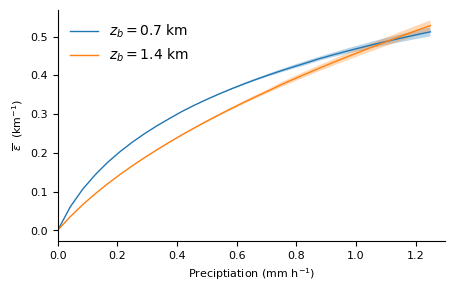

In [11]:
# For each environmental humidity, plot the precipitation entrainment rate relationship

## Set the plotting parameters
params={     
    'axes.labelsize'  : '8',   
    'axes.titlesize'  : '8',  
    'xtick.labelsize' :'8',
    'ytick.labelsize' :'8',    
    'lines.linewidth' : '1' ,   
    'legend.fontsize' : '8', 
    'figure.figsize'   : '12, 7'    
}
plt.rcParams.update(params)

# Set the model parameters
z_lcl = 700
mprofile = "cos"
df = get_Palmer_plane(z_lcl,mprofile,read_from_file=True)

## prepare arrays for plotting
sat_def_arr = np.array(df["sat_def"])*const.Lv0/1000
dh_arr = np.array(df["dh"])/1000
P_list = np.array(df["P"])/24
CAPEu_list = np.array(df["CAPE_u"])
CAPEext_list = np.array(df["CAPE_ext"])
w_arr = np.sqrt(2*CAPEext_list)
dz_arr = np.array(df["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df["ent_b"])*1000
ent_obs_arr = -np.array( dh_arr/(sat_def_arr*dz) )
RH = np.array(df["RH"])

fig = plt.figure(figsize=(5,3))

ax1 = fig.add_subplot()


I = np.abs(RH-0.5)<0.001
x = P_list[I]
y1 = ent_obs_arr[I]

I = np.abs(RH-0.98)<0.001
y2 = ent_obs_arr[I]

ax1.fill_between(x, y1, y2, alpha=0.3)
ax1.plot(x,(y1+y2)/2,label="$z_{b}= 0.7$ km")


########################
z_lcl = 1400
mprofile = "cos"
df = get_Palmer_plane(z_lcl,mprofile,read_from_file=True)

## prepare arrays for plotting
sat_def_arr = np.array(df["sat_def"])*const.Lv0/1000
dh_arr = np.array(df["dh"])/1000
P_list = np.array(df["P"])/24
CAPEu_list = np.array(df["CAPE_u"])
CAPEext_list = np.array(df["CAPE_ext"])
w_arr = np.sqrt(2*CAPEext_list)
dz_arr = np.array(df["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df["ent_b"])*1000
ent_obs_arr = -np.array( dh_arr/(sat_def_arr*dz) )
RH = np.array(df["RH"])



I = np.abs(RH-0.5)<0.001
x = P_list[I]
y1 = ent_obs_arr[I]

I = np.abs(RH-0.98)<0.001
y2 = ent_obs_arr[I]


ax1.fill_between(x, y1, y2, alpha=0.3)
ax1.plot(x,(y1+y2)/2,label="$z_{b}= 1.4$ km")

ax1.set_xlim(0,1.3)
# ax1.set_ylim(0,0.5)
ax1.set_xlabel(r"Preciptiation (mm h$^{-1}$)")
ax1.set_ylabel(r"$\overline{\epsilon}$  (km$^{-1})$")


ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)


ax1.legend(loc="upper left", frameon=False, fontsize=10)

fig.savefig("Figures/Paper/Plume_spectrum_z_LCL_comparison.pdf",bbox_inches="tight")